In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# -- Device --
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("We are using device:", device)

# -- Transforms --
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    # data augmentation: 1. flip horizontal 2. rotate five degrees 3. zoom 4. translate
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -- Settings --
SAVE_PATH = '/content/drive/MyDrive/resnet18_makeup_binary.pth'
EPOCHS = 20
LR = 1e-4

# map text labels to binary targets (0 = simple, 1 = complex)
LABEL_MAP = {'simple': 0.0, 'complex': 1.0}

# -- Dataset --
class MakeupDataSet(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        image = self.transform(image)
        # binary label: 0.0 = simple, 1.0 = complex
        label = torch.tensor(LABEL_MAP[row['complexity_label']], dtype=torch.float32)

        return image, label

# -- Load data --
IMG_DIR  = '/content/drive/MyDrive/makeup'
CSV_PATH = '/content/complexity_labels_binary.csv'

df = pd.read_csv(CSV_PATH)
print(df['complexity_label'].value_counts())

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['complexity_label']
)

print("Training images:",   len(train_df))
print("Validation images:", len(val_df))

train_loader = DataLoader(MakeupDataSet(train_df, IMG_DIR, train_tf), batch_size=32, shuffle=True)
val_loader   = DataLoader(MakeupDataSet(val_df,   IMG_DIR, val_tf),   batch_size=32, shuffle=False)

# -- Model --
model = models.resnet18(weights='IMAGENET1K_V1')
# output 1 raw logit for binary classification (BCEWithLogitsLoss applies sigmoid internally)
model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, 1))

# freeze everything first, then unfreeze layer4
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

# BCEWithLogitsLoss for binary classification
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4
)

# -- Training loop --
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total += len(labels)

    # validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * len(labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += len(labels)

            all_preds.extend(preds.squeeze(1).cpu().numpy())
            all_labels.extend(labels.squeeze(1).cpu().numpy())

    train_loss_avg = train_loss / len(train_df)
    val_loss_avg   = val_loss   / len(val_df)
    train_acc = train_correct / train_total
    val_acc   = val_correct   / val_total

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train_loss: {train_loss_avg:.4f} | "
          f"val_loss: {val_loss_avg:.4f} | train_acc: {train_acc:.3f} | val_acc: {val_acc:.3f}")

    # save model if val_acc improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> best model saved (val_acc={val_acc:.3f})")

print(f"\nDone! Best validation accuracy: {best_val_acc:.3f}")


Mounted at /content/drive
We are using device: cuda
complexity_label
simple     1604
complex    1115
Name: count, dtype: int64
Training images: 2175
Validation images: 544
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Epoch 01/20 | train_loss: 0.7034 | val_loss: 0.6566 | train_acc: 0.563 | val_acc: 0.605
  -> best model saved (val_acc=0.605)
Epoch 02/20 | train_loss: 0.7013 | val_loss: 0.6566 | train_acc: 0.573 | val_acc: 0.625
  -> best model saved (val_acc=0.625)
Epoch 03/20 | train_loss: 0.6800 | val_loss: 0.6536 | train_acc: 0.600 | val_acc: 0.640
  -> best model saved (val_acc=0.640)
Epoch 04/20 | train_loss: 0.6693 | val_loss: 0.6598 | train_acc: 0.616 | val_acc: 0.634
Epoch 05/20 | train_loss: 0.6534 | val_loss: 0.6655 | train_acc: 0.615 | val_acc: 0.632
Epoch 06/20 | train_loss: 0.6615 | val_loss: 0.6480 | train_acc: 0.619 | val_acc: 0.649
  -> best model saved (val_acc=0.649)
Epoch 07/20 | train_loss: 0.6425 | val_loss: 0.6518 | train_acc: 0.631 | val_acc: 0.649
Epoch 08/20 | train_loss: 0.6465 | val_loss: 0.6508 | train_acc: 0.642 | val_acc: 0.647
Epoch 09/20 | train_loss: 0.6291 | val_loss: 0.6545 | train_acc: 0.646 | val_acc: 0.640
Epoch 10/20 | train_loss: 0.6293 | val_loss: 0.6654 | tr

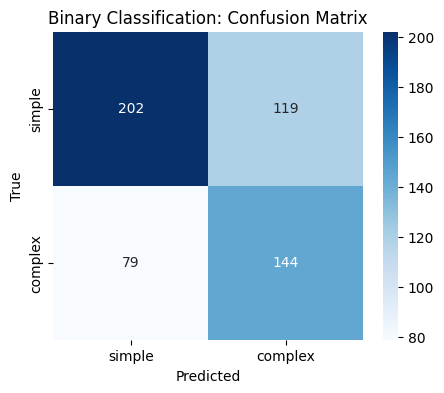

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.squeeze(1).cpu().numpy())
        all_labels.extend(labels.squeeze(1).cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
labels_names = ['simple', 'complex']

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_names, yticklabels=labels_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Binary Classification: Confusion Matrix')
plt.show()
